In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")

In [2]:
try:
    df = pd.read_csv("/content/Iris.csv")
    print("Dataset loaded from /content/Iris.csv")

except FileNotFoundError:
    iris = load_iris(as_frame=True)
    df = iris.frame.copy()

    df.columns = [
        'SepalLengthCm',
        'SepalWidthCm',
        'PetalLengthCm',
        'PetalWidthCm',
        'target'
    ]

    species_map = {
        0: 'Iris-setosa',
        1: 'Iris-versicolor',
        2: 'Iris-virginica'
    }

    df['Species'] = df['target'].map(species_map)
    df.drop(columns=['target'], inplace=True)

    df.insert(0, 'Id', range(1, len(df) + 1))

    print("Built-in sklearn Iris dataset loaded as fallback")

df.head()

Built-in sklearn Iris dataset loaded as fallback


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
print(df.describe(include='all'))

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (150, 6)

Column names:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Statistical summary:
                Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
count   150.000000     150.000000    150.000000     150.000000    150.000000   
unique         NaN            NaN           NaN            NaN           NaN   
top            NaN            NaN           NaN            NaN          

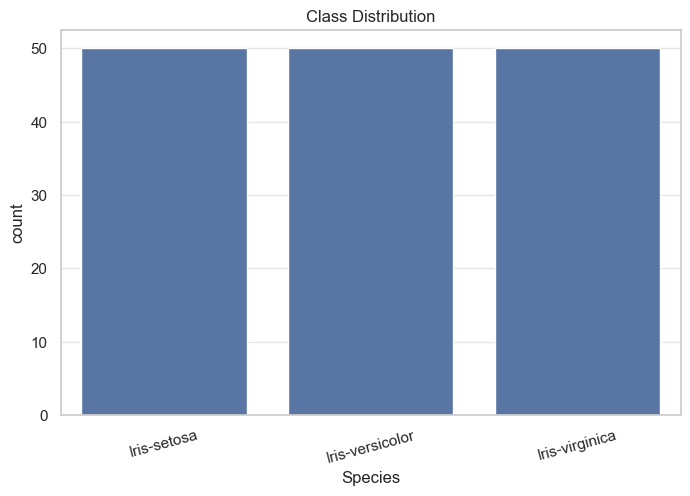

In [4]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Species')
plt.title("Class Distribution")
plt.xticks(rotation=15)
plt.show()

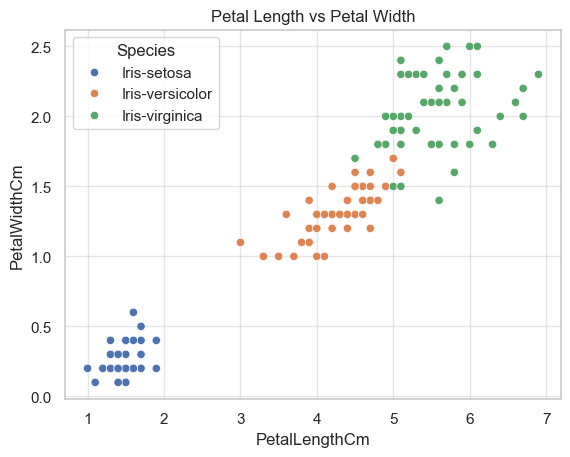

In [5]:
sns.scatterplot(x='PetalLengthCm', y='PetalWidthCm', hue='Species', data=df)
plt.title("Petal Length vs Petal Width")
plt.show()

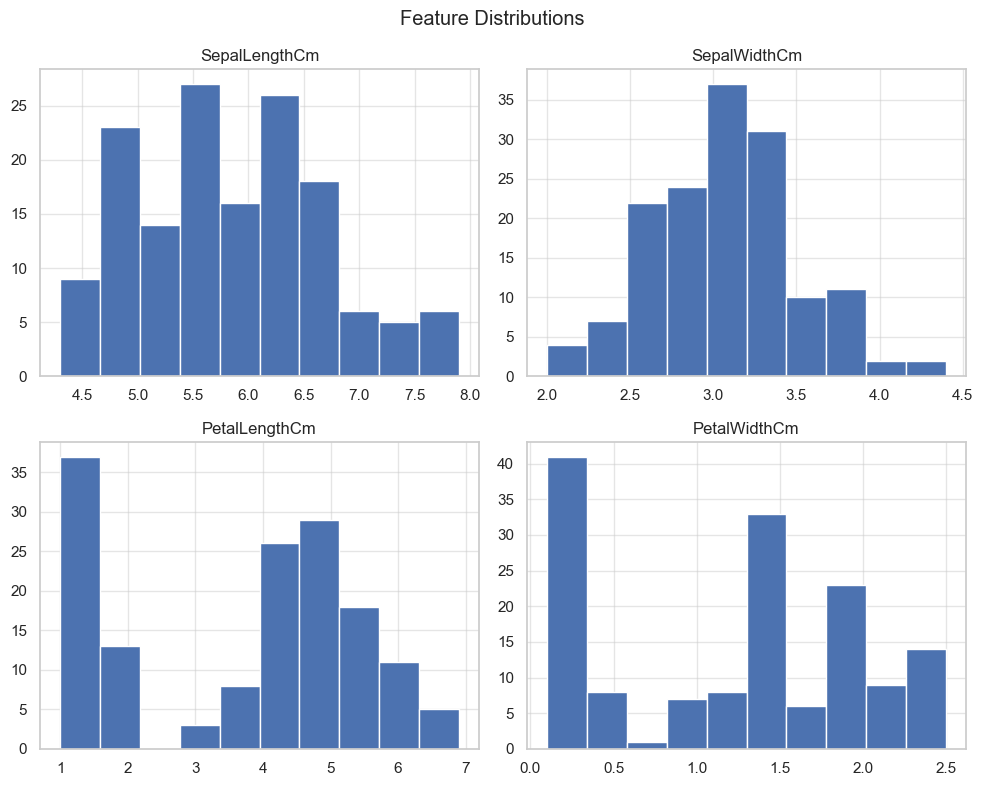

In [6]:
feature_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

df[feature_cols].hist(figsize=(10, 8))

plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

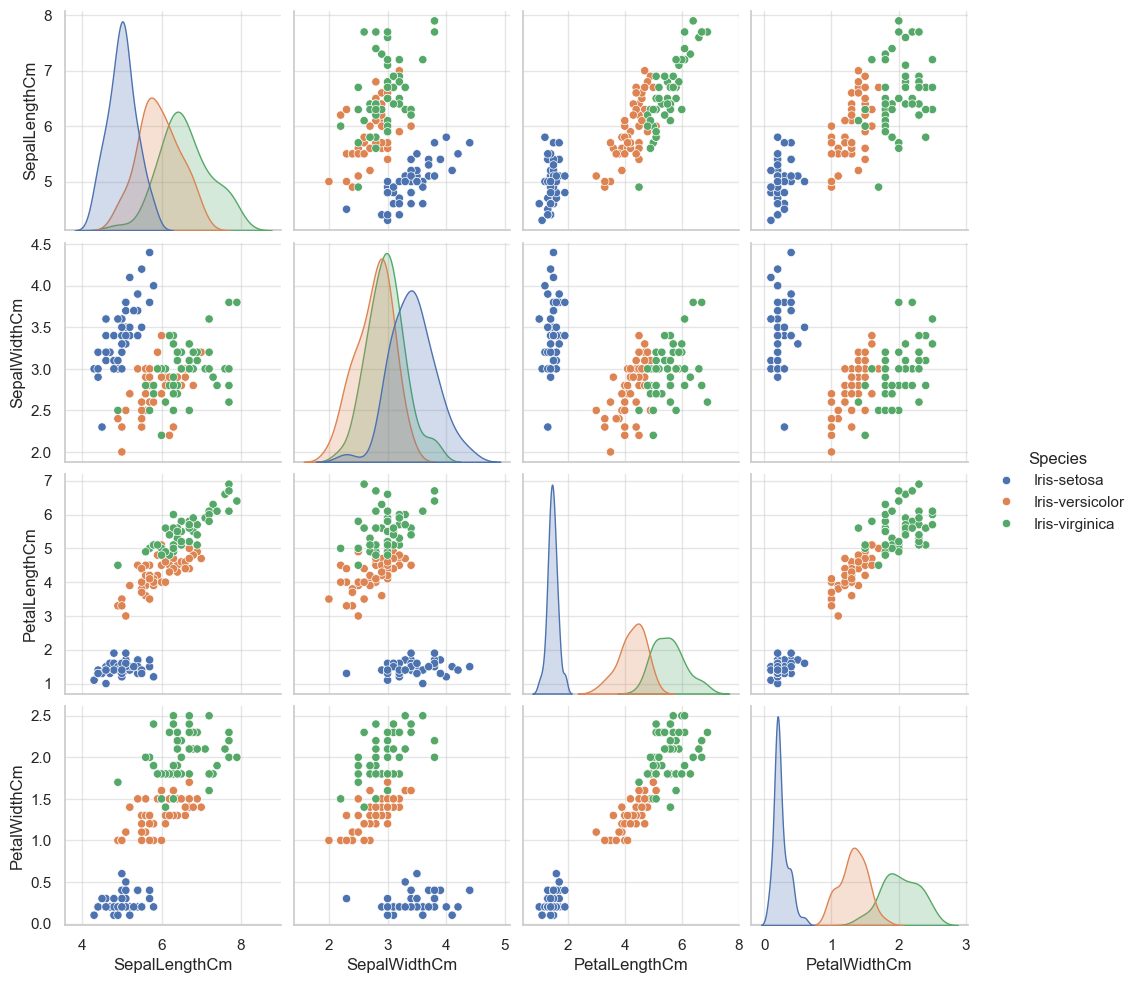

In [7]:
sns.pairplot(
    df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']],
    hue='Species'
)

plt.show()

In [10]:
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = df['Species']

imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

print("Missing values handled successfully.")
print("Feature matrix shape:", X.shape)

Missing values handled successfully.
Feature matrix shape: (150, 4)


In [11]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Class labels:")
for idx, label in enumerate(label_encoder.classes_):
    print(f"{idx} -> {label}")

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nScaled feature sample:")
print(X_scaled[:5])

Class labels:
0 -> Iris-setosa
1 -> Iris-versicolor
2 -> Iris-virginica

Scaled feature sample:
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (120, 4)
Testing set size: (30, 4)


In [13]:
model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:10])

Predictions:
[0 2 1 1 0 1 0 0 2 1]


In [14]:
accuracy = accuracy_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

report = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n", report)

Accuracy: 0.9333333333333333

Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



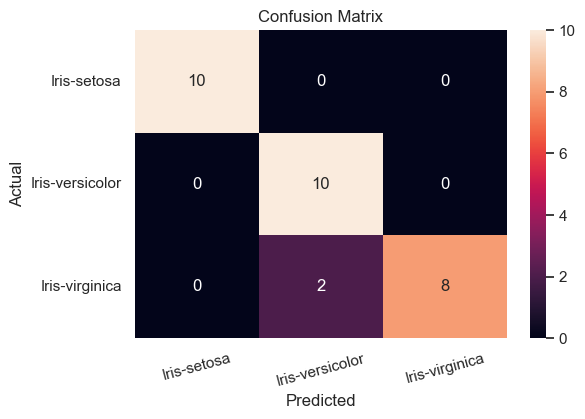

In [15]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(rotation=15)
plt.yticks(rotation=0)

plt.show()

,K,Accuracy
0,1,0.966667
1,2,0.933333
2,3,0.933333
3,4,0.933333
4,5,0.933333
5,6,0.933333
6,7,0.966667
7,8,0.933333
8,9,0.966667
9,10,0.966667


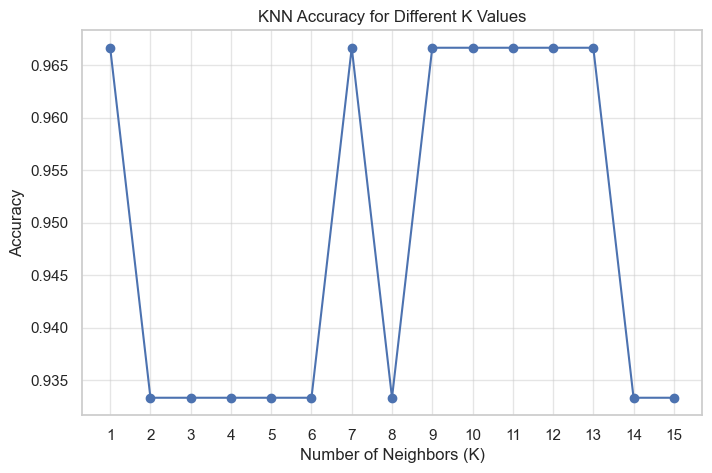

In [16]:
k_values = list(range(1, 16))
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, pred_k))

results_df = pd.DataFrame({
    "K": k_values,
    "Accuracy": accuracies
})

display(results_df)

plt.figure(figsize=(8, 5))

plt.plot(k_values, accuracies, marker='o')

plt.title("KNN Accuracy for Different K Values")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")

plt.xticks(k_values)

plt.show()